# Depandancy Package

In [76]:
import mne
import numpy as np
from mne.channels import make_standard_montage
from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold , train_test_split , GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import os

# Dataset Setting

In [77]:
# Select dataset
# 0: BCICIV_2a
# 1: BCICIV_2b
Dataset_Selection = 0


match Dataset_Selection:
    case 0:
        gdf_dirPath = f'../../dataset/BCICIV_2a_gdf/' # GDF read dir path
        participants = [] # EEG-MI 受試者
        participantsNum = 9 # EEG-MI 受試者人數
        for i in range(1,participantsNum+1,1):
            participants = participants + [f'A0{i}T']  # bci4_2A
        saveResultPath = './result_bci4_2a/' # 結果儲存資料夾
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2A 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG-Fz' : 'Fz'  ,
            'EEG-0'  : 'FC3' ,
            'EEG-1'  : 'FC1' ,
            'EEG-2'  : 'FCz' ,
            'EEG-3'  : 'FC2' ,
            'EEG-4'  : 'FC4' ,
            'EEG-5'  : 'C5'  ,
            'EEG-C3' : 'C3'  ,
            'EEG-6'  : 'C1'  ,
            'EEG-Cz' : 'Cz'  ,
            'EEG-7'  : 'C2'  ,
            'EEG-C4' : 'C4'  ,
            'EEG-8'  : 'C6'  ,
            'EEG-9'  : 'CP3' ,
            'EEG-10' : 'CP1' ,
            'EEG-11' : 'CPz' ,
            'EEG-12' : 'CP2' ,
            'EEG-13' : 'CP4' ,
            'EEG-14' : 'P1'  ,
            'EEG-Pz' : 'Pz'  ,
            'EEG-15' : 'P2'  ,
            'EEG-16' : 'POz' ,
            'EOG-left'   : 'EOG-left',
            'EOG-central': 'EOG-central',
            'EOG-right'  : 'EOG-right'
        }
        channel_types = {
            'EEG-Fz' : 'eeg',
            'EEG-0'  : 'eeg',
            'EEG-1'  : 'eeg',
            'EEG-2'  : 'eeg',
            'EEG-3'  : 'eeg',
            'EEG-4'  : 'eeg',
            'EEG-5'  : 'eeg',
            'EEG-C3' : 'eeg',
            'EEG-6'  : 'eeg',
            'EEG-Cz' : 'eeg',
            'EEG-7'  : 'eeg',
            'EEG-C4' : 'eeg',
            'EEG-8'  : 'eeg',
            'EEG-9'  : 'eeg',
            'EEG-10' : 'eeg',
            'EEG-11' : 'eeg',
            'EEG-12' : 'eeg',
            'EEG-13' : 'eeg',
            'EEG-14' : 'eeg',
            'EEG-Pz' : 'eeg',
            'EEG-15' : 'eeg',
            'EEG-16' : 'eeg',
            'EOG-left'   : 'eog',
            'EOG-central': 'eog',
            'EOG-right'  : 'eog'
        }
    case 1:
        gdf_dirPath = f'../../dataset/BCICIV_2b_gdf/'
        participants = []
        participantsNum = 9
        for i in range(1,participantsNum+1,1):
            participants = participants + [f'B0{i}03T']  # bci4_2B
        saveResultPath = './result_bci4_2b/'
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2B 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG:C3' : 'C3'  ,
            'EEG:Cz' : 'Cz'  ,
            'EEG:C4' : 'C4'  ,
            'EOG:ch01':'EOG:ch01',
            'EOG:ch02':'EOG:ch02',
            'EOG:ch03':'EOG:ch03'
        }
        channel_types = {
            'EEG:C3'   : 'eeg',
            'EEG:Cz'   : 'eeg',
            'EEG:C4'   : 'eeg',
            'EOG:ch01' : 'eog',
            'EOG:ch02' : 'eog',
            'EOG:ch03' : 'eog'
        }

try:
    os.mkdir(saveResultPath) # 創建結果儲存資料夾
except:
    print("file exist")
    pass

file exist


# Pre-Processing Setting

In [78]:
# band pass filter
fs = 250
lowcut = 5
highcut = 15
filter_order = 4
filter_type = 'butter' # Butterworth
iir_params = dict(order=filter_order, ftype=filter_type)

# 擷取實驗時間，0秒是cued開始
# C: number of channels
# P: number of temporal points
# N: number of trials
# (tmax-tmin)*250+1=500
# tmax = (P-1)/fs+tmin
time_interval = 5.5
P = time_interval*fs
tmin = 0.5
tmax = (P-1)/fs+tmin

# CSP M值
M = 3

# Data Segmentation and Splitting

In [79]:
montage = make_standard_montage('standard_1020')
eeg_only_channels = [
    name
    for name in channel_rename_map.values()
    if not name.startswith('EOG')
]

## Create Epoch training data and testing data
epochs = {}
for subject in participants:
    gdf_filepath = gdf_dirPath + f'./{subject}.gdf'
    try:
        raw = mne.io.read_raw_gdf(gdf_filepath, preload=True, verbose="ERROR")
    except Exception as e:
        print(f"讀取 GDF 檔案時發生錯誤: {e}")
        raise
    ## Raw setting
    raw.set_channel_types(channel_types, verbose="ERROR") # 設定電擊種類是EEG還是EOG
    raw.set_eeg_reference([], verbose="ERROR") # 設定reference電擊
    raw.rename_channels(channel_rename_map, verbose="ERROR") # 重新命名電擊名稱符合10-20系統
    raw.set_montage(montage, on_missing='ignore', verbose="ERROR") # 設定10-20系統

    ## Regression
    # model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
    # model.fit(raw)
    # raw = model.apply(raw)

    raw.pick_channels(eeg_only_channels, verbose="ERROR") # Remove EOG data
    raw.filter( # Bandpass filter
        l_freq=lowcut,
        h_freq=highcut,
        method='iir',
        iir_params=iir_params,
        verbose="ERROR"
    )

    ## 選取事件做成epoch
    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    kept_event_ids = {
        key: value
        for key, value in event_id.items()
        if key in target_keys
    }
    events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
    baseline = None # 不做基線校正，或您可以定義 (-0.5, 0)
    epoch = mne.Epochs(
        raw,
        events_of_interest,
        event_id=kept_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,        # 將數據載入內存
        proj=False,           # 暫時不應用投影
        verbose="ERROR"
    )
    epochs[subject] = epoch
    print(f"{subject} epoch create successful")

A01T epoch create successful
A02T epoch create successful
A03T epoch create successful
A04T epoch create successful
A05T epoch create successful
A06T epoch create successful
A07T epoch create successful
A08T epoch create successful
A09T epoch create successful


# Feature Transfer (CSP)

In [80]:
## CSP training
feat = {}
for subject in participants:
    n_components = 2*M
    csp = CSP(
        n_components=n_components,
        reg=None, # 正則化參數，通常保持 None
        log=True,
        transform_into='average_power' # 轉換成平均功率 (方差的對數)
    )
    X = epochs[subject].get_data()
    X = X - np.mean(X, axis=-1, keepdims=True)
    X_T = np.transpose(X, axes=(0, 2, 1))
    cov = X @ X_T
    feat_before = np.log(np.diagonal(cov, axis1=1, axis2=2)/P)
    y = epochs[subject].events[:, 2]
    X_csp = csp.fit_transform(X, y)
    feat[subject] = {
            'before':   feat_before,
            'after':    X_csp,
            'event':    2*(y-np.min(np.array(list(set(list(y))))))-1
        }

Computing rank from data with rank=None
    Using tolerance 8.8e-05 (2.2e-16 eps * 22 dim * 1.8e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 9.3e-05 (2.2e-16 eps * 22 dim * 1.9e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 9.1e-05 (2.2e-16 eps * 22 dim * 1.9e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

# 112 CSP (可刪除)

In [ ]:
def manual_csp_final(X, y):
    # 1. 類別分離與 Trace Normalization
    labels = np.unique(y)
    def get_norm_cov(data):
        # data: (trials, channels, samples)
        nt, nc, ns = data.shape
        # 計算每個 trial 的協方差並歸一化
        cov_list = [(d @ d.T) / ns for d in data]
        # Trace normalization 避免能量偏置
        cov_norm = [c / np.trace(c) for c in cov_list]
        return np.mean(cov_norm, axis=0)

    cov0 = get_norm_cov(X[y == labels[0]])
    cov1 = get_norm_cov(X[y == labels[1]])

    # 2. 解廣義特徵值問題
    # 使用 eigh 處理對稱矩陣，確保數值穩定
    evals, evecs = np.linalg.eigh(cov0, cov0 + cov1)

    # 3. 排序：模仿 MNE 的 $|lambda - 0.5|$ 邏輯
    # 這樣前幾個特徵就會包含「對第一類最有利」與「對第二類最有利」的組合
    sort_idx = np.argsort(np.abs(evals - 0.5))[::-1]
    W = evecs[:, sort_idx].T
    return W

In [82]:
## 112 CXLin CSP
def manual_cov(trials):
    ''' Calculate the covariance for each trial and return their average '''
    n_channels, nsamples, ntrials = trials.shape
    # covs = [ (trials[:,:,i] @ trials[:,:,i].T) / nsamples for i in range(ntrials) ]
    # # print(f"covs: {covs.shape}")
    # traces = np.trace(covs, axis1=1, axis2=2)
    # return np.mean(covs, axis=0)
    covs = []
    for i in range(ntrials):
        # 取出單一 trial (C, S)
        E = trials[:, :, i]
        c = (E @ E.T) / nsamples
        # MNE 的核心步驟：Trace Normalization
        covs.append(c / np.trace(c))
    return np.mean(covs, axis=0)

def whitening(sigma):
    ''' Calculate a whitening matrix for covariance matrix sigma. '''
    U, l, _ = np.linalg.svd(sigma)
    return U @ np.diag(l ** -0.5)

def manual_csp(X, y):
    '''
    Calculate the CSP transformation matrix W.
    arguments:
        trials_r - Array (channels x samples x trials) containing right hand movement trials
        trials_f - Array (channels x samples x trials) containing foot movement trials
    returns:
        Mixing matrix W
    '''
    labels = np.unique(y)
    trials_r = np.transpose(X[y == labels[0]], (1, 2, 0))
    trials_f = np.transpose(X[y == labels[1]], (1, 2, 0))
    # trials_r = np.transpose(X[np.where(y==list(set(list(y)))[0])], axes=(1, 2, 0))
    # trials_f = np.transpose(X[np.where(y==list(set(list(y)))[1])], axes=(1, 2, 0))
    cov_r = manual_cov(trials_r)
    cov_f = manual_cov(trials_f)
    P = whitening(cov_r + cov_f)
    # B, _, _ = np.linalg.svd( P.T.dot(cov_f).dot(P) )
    B, s, _ = np.linalg.svd(P.T @ cov_f @ P)
    W = (P @ B).T
    # W = P.dot(B)
    return W

def extract_features(W, data):
    # data: (trials, channels, samples)
    W_idx = np.concatenate([np.arange(M), np.arange(-M, 0)])
    W_selected = W[W_idx]
    feats = []
    for i in range(data.shape[0]):
        # 投影: (2M, C) @ (C, S) -> (2M, S)
        z = W_selected @ data[i]
        # 計算變異量並取 log
        var = np.var(z, axis=1)
        feats.append(np.log(var))
    return np.array(feats)
    # feat = []
    # for i in range(data.shape[0]):
    #     # 投影: (2, channels) @ (channels, samples) -> (2, samples)
    #     W_i = np.concat((W_manual[:M], W_manual[-M:]), axis=0)
    #     z = W_i @ data[i]
    #     var = np.var(z, axis=1)
    #     feat.append(np.log(var))
    # return np.array(feat)

feat_manual = {}
for subject in participants:
    X = epochs[subject].get_data()
    X = X - np.mean(X, axis=-1, keepdims=True)
    X_T = np.transpose(X, axes=(0, 2, 1))
    cov = X @ X_T
    feat_before = np.log(np.diagonal(cov, axis1=1, axis2=2)/P)
    y = epochs[subject].events[:, 2]

    # W_manual = manual_csp(X, y)
    W_manual = manual_csp_final(X, y)
    X_csp = extract_features(W_manual, X)
    # print(X.shape)
    # print(X_csp.shape)
    # print(W_manual.shape)
    feat_manual[subject] = {
            'before':   feat_before,
            'after':    X_csp,
            'event':    2*(y-np.min(np.array(list(set(list(y))))))-1
        }


AttributeError: 'numpy.ndarray' object has no attribute 'upper'

# Feature Visualization (Compare)

mne
X shape before: (144, 22)
X shape after : (144, 6)
manual
X shape before: (144, 22)
X shape after : (144, 6)
Before X detect
True
--- CSP 前 ---
Fisher Score: 5.1379, Silhouette: 0.0027, DBI: 8.7398
--- CSP 後 ---
Fisher Score: 46.5217, Silhouette: 0.1017, DBI: 2.4952
=== (144, 22)
--- Manual CSP 前 ---
Fisher Score: 5.1379, Silhouette: 0.0027, DBI: 8.7398
--- Manual CSP 後 ---
Fisher Score: 40.5389, Silhouette: 0.0928, DBI: 2.7797


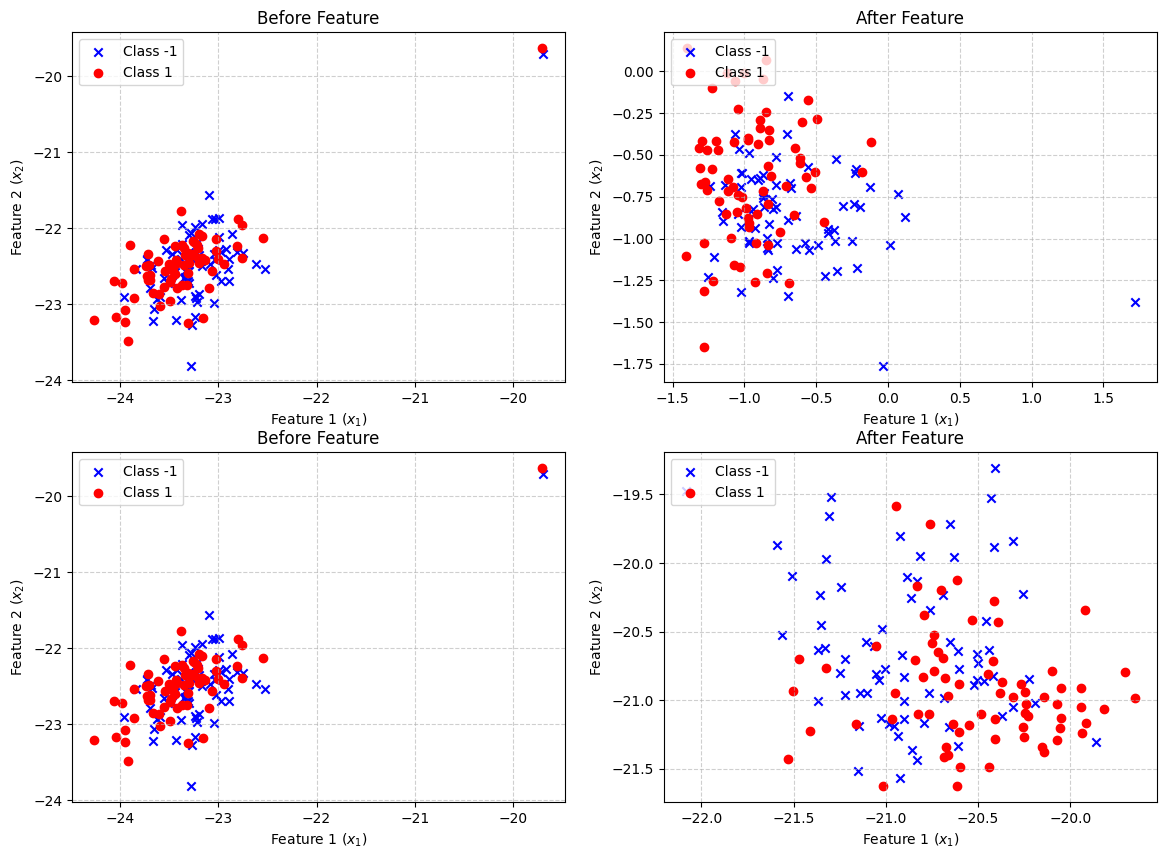

Total samples: 144


In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.feature_selection import f_classif

def calculate_separation_metrics(X, y):
    # 1. 計算 Fisher Score
    f_scores, p_values = f_classif(X, y)
    f_score_2norm = np.sum(f_scores**2)**0.5

    # 2. 計算 Silhouette Score
    s_score = silhouette_score(X, y)

    # 3. 計算 Davies-Bouldin Index
    db_index = davies_bouldin_score(X, y)

    return f_score_2norm, s_score, db_index

# 使用範例
# X_pre = feat[subject]['before']
# X_post = feat[subject]['after']
# y = feat[subject]['event']
print(f"mne")
print(f"X shape before: {feat[subject]['before'].shape}")
print(f"X shape after : {feat[subject]['after'].shape}")

print(f"manual")
print(f"X shape before: {feat_manual[subject]['before'].shape}")
print(f"X shape after : {feat_manual[subject]['after'].shape}")

print(f"Before X detect")
print(np.array_equal(feat[subject]['before'], feat_manual[subject]['before']))

y = feat[subject]['event']
f_pre, s_pre, d_pre = calculate_separation_metrics(feat[subject]['before'], y)
f_post, s_post, d_post = calculate_separation_metrics(feat[subject]['after'], y)

print(f"--- CSP 前 ---")
print(f"Fisher Score: {f_pre:.4f}, Silhouette: {s_pre:.4f}, DBI: {d_pre:.4f}")
print(f"--- CSP 後 ---")
print(f"Fisher Score: {f_post:.4f}, Silhouette: {s_post:.4f}, DBI: {d_post:.4f}")

## Before
X = feat[subject]['before']
print(f"=== {X.shape}")
# --- 繪圖視覺化 ---
# fig, ax = plt.subplots(2, 2, figsize=(10, 7), subplot_kw={'projection': '3d'})
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 畫出類別 -1 的點 (利用布林索引)
ax[0][0].scatter(X[y == -1, 0], X[y == -1, -1],
            color='blue', marker='x', label='Class -1')
# 畫出類別 1 的點
ax[0][0].scatter(X[y == 1, 0], X[y == 1, -1],
            color='red', marker='o', label='Class 1')
ax[0][0].set_xlabel('Feature 1 ($x_1$)')
ax[0][0].set_ylabel('Feature 2 ($x_2$)')
# ax[0][0].set_zlabel('Feature 3 ($x_3$)')
ax[0][0].set_title('Before Feature')
ax[0][0].legend(loc='upper left')
ax[0][0].grid(True, linestyle='--', alpha=0.6)

## After
X = feat[subject]['after']
# 畫出類別 -1 的點 (利用布林索引)
ax[0][1].scatter(X[y == -1, 0], X[y == -1, -1],
            color='blue', marker='x', label='Class -1')
# 畫出類別 1 的點
ax[0][1].scatter(X[y == 1, 0], X[y == 1, -1],
            color='red', marker='o', label='Class 1')
ax[0][1].set_xlabel('Feature 1 ($x_1$)')
ax[0][1].set_ylabel('Feature 2 ($x_2$)')
# ax[0][1].set_zlabel('Feature 3 ($x_3$)')
ax[0][1].set_title('After Feature')
ax[0][1].legend(loc='upper left')
ax[0][1].grid(True, linestyle='--', alpha=0.6)

### manual

y = feat_manual[subject]['event']
f_pre, s_pre, d_pre = calculate_separation_metrics(feat_manual[subject]['before'], y)
f_post, s_post, d_post = calculate_separation_metrics(feat_manual[subject]['after'], y)

print(f"--- Manual CSP 前 ---")
print(f"Fisher Score: {f_pre:.4f}, Silhouette: {s_pre:.4f}, DBI: {d_pre:.4f}")
print(f"--- Manual CSP 後 ---")
print(f"Fisher Score: {f_post:.4f}, Silhouette: {s_post:.4f}, DBI: {d_post:.4f}")

## Before
X = feat_manual[subject]['before']

# 畫出類別 -1 的點 (利用布林索引)
ax[1][0].scatter(X[y == -1, 0], X[y == -1, -1],
            color='blue', marker='x', label='Class -1')
# 畫出類別 1 的點
ax[1][0].scatter(X[y == 1, 0], X[y == 1, -1],
            color='red', marker='o', label='Class 1')
ax[1][0].set_xlabel('Feature 1 ($x_1$)')
ax[1][0].set_ylabel('Feature 2 ($x_2$)')
# ax[1][0].set_zlabel('Feature 3 ($x_3$)')
ax[1][0].set_title('Before Feature')
ax[1][0].legend(loc='upper left')
ax[1][0].grid(True, linestyle='--', alpha=0.6)

## After
X = feat_manual[subject]['after']
# 畫出類別 -1 的點 (利用布林索引)
ax[1][1].scatter(X[y == -1, 0], X[y == -1, -1],
            color='blue', marker='x', label='Class -1')
# 畫出類別 1 的點
ax[1][1].scatter(X[y == 1, 0], X[y == 1, -1],
            color='red', marker='o', label='Class 1')
ax[1][1].set_xlabel('Feature 1 ($x_1$)')
ax[1][1].set_ylabel('Feature 2 ($x_2$)')
# ax[1][1].set_zlabel('Feature 3 ($x_3$)')
ax[1][1].set_title('After Feature')
ax[1][1].legend(loc='upper left')
ax[1][1].grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Total samples: {len(X)}")

# end

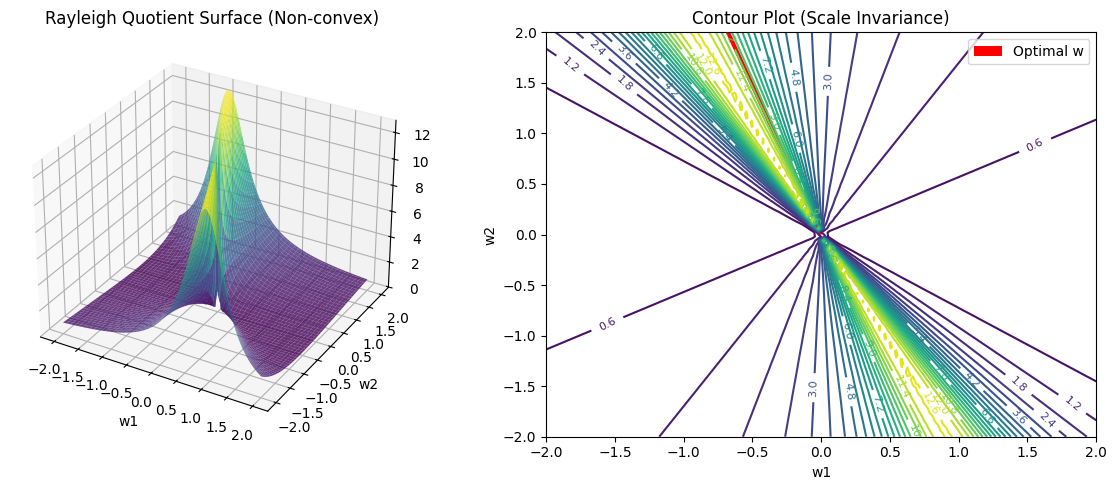

Optimal w found by GEP: [-1.23898929  2.68517949]
Original J(w): 12.653301
Scaled J(2.5w): 12.653301


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

def visualize_gep_surface():
    # 1. 生成隨機正定矩陣 (確保可重複性)
    np.random.seed(42)
    A = np.random.randn(2, 2)
    Sigma1 = A.T @ A + np.eye(2)*0.1
    B = np.random.randn(2, 2)
    Sigma2 = B.T @ B + np.eye(2)*0.1

    # 2. 求解廣義特徵值問題 Sigma1 * w = lambda * Sigma2 * w
    # eigh 可以直接求解 GEP
    vals, vecs = eigh(Sigma1, Sigma2)
    best_w = vecs[:, -1] # 最大特徵值對應的特徵向量

    # 3. 準備繪圖數據
    x = np.linspace(-2, 2, 100)
    y = np.linspace(-2, 2, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)

    for i in range(len(x)):
        for j in range(len(y)):
            w = np.array([X[i,j], Y[i,j]])
            if np.allclose(w, 0):
                Z[i,j] = 0
            else:
                # 計算瑞利商
                Z[i,j] = (w.T @ Sigma1 @ w) / (w.T @ Sigma2 @ w)

    # 4. 繪圖
    fig = plt.figure(figsize=(12, 5))

    # 3D 表面圖
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    ax1.set_title("Rayleigh Quotient Surface (Non-convex)")
    ax1.set_xlabel("w1")
    ax1.set_ylabel("w2")

    # 等高線圖 (展示尺度不變性：放射狀線條)
    ax2 = fig.add_subplot(122)
    cp = ax2.contour(X, Y, Z, levels=20)
    ax2.clabel(cp, inline=True, fontsize=8)
    ax2.quiver(0, 0, best_w[0], best_w[1], color='r', scale=5, label='Optimal w')
    ax2.set_title("Contour Plot (Scale Invariance)")
    ax2.set_xlabel("w1")
    ax2.set_ylabel("w2")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"Optimal w found by GEP: {best_w}")
    # 驗證尺度不變性
    w_scaled = best_w * 2.5
    val_orig = (best_w.T @ Sigma1 @ best_w) / (best_w.T @ Sigma2 @ best_w)
    val_scaled = (w_scaled.T @ Sigma1 @ w_scaled) / (w_scaled.T @ Sigma2 @ w_scaled)
    print(f"Original J(w): {val_orig:.6f}")
    print(f"Scaled J(2.5w): {val_scaled:.6f}")

if __name__ == "__main__":
    visualize_gep_surface()